In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visits_a = pd.read_csv('old_shop_visits.csv')
visits_b = pd.read_csv('new_shop_visits.csv')
orders_a = pd.read_csv('old_shop_orders.csv')
orders_b = pd.read_csv('new_shop_orders.csv')

In [3]:
visits_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            72 non-null     int64 
 1   user_id       72 non-null     object
 2   group         72 non-null     object
 3   visit_date    72 non-null     object
 4   device        72 non-null     object
 5   page_views    72 non-null     int64 
 6   time_spent    72 non-null     int64 
 7   total_amount  72 non-null     int64 
 8   session_id    72 non-null     object
dtypes: int64(4), object(5)
memory usage: 5.2+ KB


In [4]:
visits_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            127 non-null    int64 
 1   user_id       127 non-null    object
 2   group         127 non-null    object
 3   visit_date    127 non-null    object
 4   device        127 non-null    object
 5   page_views    127 non-null    int64 
 6   time_spent    127 non-null    int64 
 7   total_amount  127 non-null    int64 
 8   session_id    127 non-null    object
dtypes: int64(4), object(5)
memory usage: 9.1+ KB


In [5]:
orders_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                32 non-null     int64  
 1   order_date        32 non-null     object 
 2   product_names     26 non-null     object 
 3   quantities        26 non-null     object 
 4   total_cost        32 non-null     float64
 5   customer_name     32 non-null     object 
 6   customer_email    32 non-null     object 
 7   delivery_address  32 non-null     object 
 8   user_id           32 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.4+ KB


In [6]:
orders_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                65 non-null     int64  
 1   order_date        65 non-null     object 
 2   product_names     64 non-null     object 
 3   quantities        64 non-null     object 
 4   total_cost        65 non-null     float64
 5   customer_name     65 non-null     object 
 6   customer_email    65 non-null     object 
 7   delivery_address  65 non-null     object 
 8   user_id           63 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 4.7+ KB


In [7]:
orders_a.dropna(inplace=True)
orders_b.dropna(inplace=True)

In [8]:
orders_a.info()
orders_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26 entries, 3 to 30
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                26 non-null     int64  
 1   order_date        26 non-null     object 
 2   product_names     26 non-null     object 
 3   quantities        26 non-null     object 
 4   total_cost        26 non-null     float64
 5   customer_name     26 non-null     object 
 6   customer_email    26 non-null     object 
 7   delivery_address  26 non-null     object 
 8   user_id           26 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 64
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                62 non-null     int64  
 1   order_date        62 non-null     object 
 2   product_names     62 non-null     

In [9]:
orders_a['group'] = 'A'
orders_b['group'] = 'B'

In [10]:
visits = pd.concat([visits_a, visits_b], ignore_index=True)
orders = pd.concat([orders_a, orders_b], ignore_index=True)

In [ ]:
unique_users = visits.groupby('group')['user_id'].nunique()
unique_buyers = orders.groupby('group')['user_id'].nunique()

conversion_users = (unique_buyers / unique_users) * 100

print('Конверсия в покупку по пользователям (%):')
print(conversion_users)

Конверсия в покупку по пользователям (%):
group
A    27.659574
B    44.927536
Name: user_id, dtype: float64


In [ ]:
total_visits = visits.groupby('group')['session_id'].count()
orders_per_visit = visits.groupby('group')['total_amount'].sum()

conversion_visits = (orders_per_visit / total_visits) * 100

print('\nКонверсия в покупку по визитам (%):')
print(conversion_visits)



Конверсия в покупку по визитам (%):
group
A    30.555556
B    36.220472
dtype: float64


In [13]:
successes = [unique_buyers['B'], unique_buyers['A']]  # Число пользователей с заказами в группах B и A
trials = [unique_users['B'], unique_users['A']]  # Общее число пользователей в группах B и A

z_stat, p_value_users = proportions_ztest(successes, trials)
print('\nP-value для конверсии по пользователям:', f'{p_value_users:.3f}')

successes = [orders_per_visit['B'], orders_per_visit['A']]
trials = [total_visits['B'], total_visits['A']]
z_stat, p_value_visits = proportions_ztest(successes, trials)
print('P-value для конверсии по визитам:', f'{p_value_visits:.3f}')


P-value для конверсии по пользователям: 0.060
P-value для конверсии по визитам: 0.418


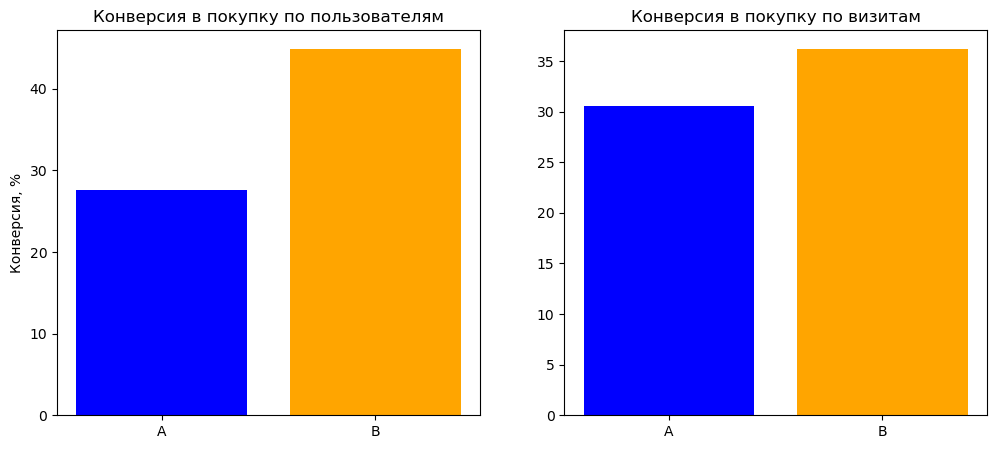

In [14]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(conversion_users.index, conversion_users.values, color=['blue', 'orange'])
ax[0].set_title('Конверсия в покупку по пользователям')
ax[0].set_ylabel('Конверсия, %')

ax[1].bar(conversion_visits.index, conversion_visits.values, color=['blue', 'orange'])
ax[1].set_title('Конверсия в покупку по визитам')

plt.show()

In [15]:
def bootstrap_conversion(visits, orders, n_samples=1000):
    conversions = []
    for _ in range(n_samples):
        sample_visits = np.random.choice([0, 1], size=visits, p=[1 - orders / visits, orders / visits])
        conversions.append(np.mean(sample_visits))
    return conversions

In [16]:
visits_per_group = visits.groupby('group')['session_id'].count()
unique_users_per_group = visits.groupby('group')['user_id'].nunique()

orders_per_group = orders.groupby('group')['id'].count()
unique_buyers_per_group = orders.groupby('group')['user_id'].nunique()

visits_per_group, unique_buyers_per_group, orders_per_group, unique_users_per_group

(group
 A     72
 B    127
 Name: session_id, dtype: int64,
 group
 A    13
 B    31
 Name: user_id, dtype: int64,
 group
 A    26
 B    62
 Name: id, dtype: int64,
 group
 A    47
 B    69
 Name: user_id, dtype: int64)

In [17]:
boot_a = bootstrap_conversion(visits_per_group['A'], orders_per_group['A'])
boot_b = bootstrap_conversion(visits_per_group['B'], orders_per_group['B'])

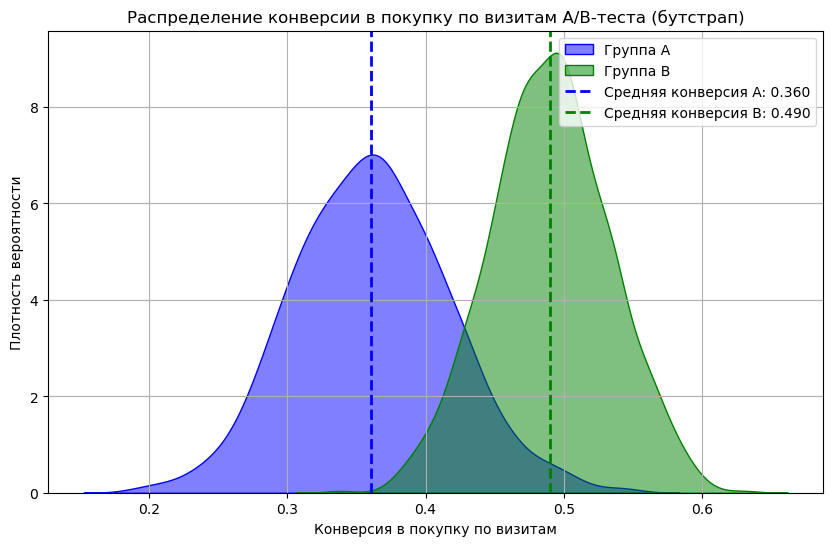

In [18]:
plt.figure(figsize=(10, 6))
sns.kdeplot(boot_a, label='Группа A', fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b, label='Группа B', fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a), color='blue', linestyle='dashed', linewidth=2, label=f'Средняя конверсия A: {np.mean(boot_a):.3f}')
plt.axvline(np.mean(boot_b), color='green', linestyle='dashed', linewidth=2, label=f'Средняя конверсия B: {np.mean(boot_b):.3f}')
plt.xlabel('Конверсия в покупку по визитам')
plt.ylabel('Плотность вероятности')
plt.title('Распределение конверсии в покупку по визитам A/B-теста (бутстрап)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
boot_unique_a = bootstrap_conversion(unique_users_per_group['A'], unique_buyers_per_group['A'])
boot_unique_b = bootstrap_conversion(unique_users_per_group['B'], unique_buyers_per_group['B'])

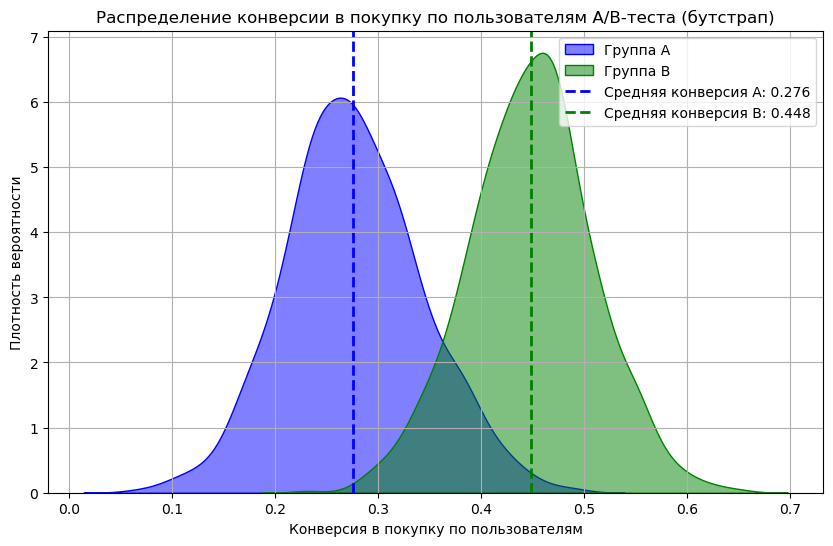

In [20]:
plt.figure(figsize=(10, 6))
sns.kdeplot(boot_unique_a, label='Группа A', fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_unique_b, label='Группа B', fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_unique_a), color='blue', linestyle='dashed', linewidth=2, label=f'Средняя конверсия A: {np.mean(boot_unique_a):.3f}')
plt.axvline(np.mean(boot_unique_b), color='green', linestyle='dashed', linewidth=2, label=f'Средняя конверсия B: {np.mean(boot_unique_b):.3f}')
plt.xlabel('Конверсия в покупку по пользователям')
plt.ylabel('Плотность вероятности')
plt.title('Распределение конверсии в покупку по пользователям A/B-теста (бутстрап)')
plt.legend()
plt.grid(True)
plt.show()